In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
drive_path = '/content/drive/MyDrive/Alzheimer_Final_Processed'
local_path = '/content/Train_Data'

if not os.path.exists(local_path):
    import shutil
    shutil.copytree(drive_path, local_path)
    print(" Preprocessed data successfully transferred from Drive to Local.")

 Preprocessed data successfully transferred from Drive to Local.


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

img_size = (224, 224)
batch_size = 32

train_generator = train_datagen.flow_from_directory(
    '/content/Train_Data/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/Train_Data/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/Train_Data/test',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

print(f"Data Pipeline Ready for ResNet50. Mapping: {train_generator.class_indices}")


Found 14000 images belonging to 4 classes.
Found 3000 images belonging to 4 classes.
Found 3000 images belonging to 4 classes.
Data Pipeline Ready for ResNet50. Mapping: {'MildDemented': 0, 'ModerateDemented': 1, 'NonDemented': 2, 'VeryMildDemented': 3}


In [ ]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models, optimizers

base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3)) # Load ResNet50 with pre-trained ImageNet weights excluding the top classification layer

base_model.trainable = False                                                     # Freeze the convolutional base to retain pre-trained feature extraction knowledge

model = models.Sequential([                                                      # Define the custom architecture by stacking layers sequentially
    base_model,                                                                  # Incorporate the frozen ResNet50 base as the initial feature extractor
    layers.GlobalAveragePooling2D(),                                             # Reduce spatial dimensions into a fixed-length feature vector
    layers.BatchNormalization(),                                                 # Normalize activations to accelerate convergence and improve stability

    layers.Dense(256, activation='relu'),                                        # Add a fully connected layer with 256 neurons for high-level feature learning
    layers.Dropout(0.4),                                                         # Apply dropout regularization to prevent overfitting during training

    layers.Dense(4, activation='softmax')                                        # Final output layer with softmax activation for 4-class Alzheimer diagnosis
])

model.compile(                                                                   # Configure the model for the training process
    optimizer=optimizers.Adam(learning_rate=0.0001),                             # Use Adam optimizer with a low learning rate for precise transfer learning
    loss='categorical_crossentropy',                                              # Set categorical crossentropy for multi-class probability distribution
    metrics=['accuracy']                                                         # Track accuracy as the primary performance metric
)

model.summary()                                                                  # Print a detailed architectural summary of the model and its parameters

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         1,028 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,121,476 (92.02 MB)

 Trainable params: 529,668 (2.02 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

In [ ]:
from tensorflow.keras.models import load_model

# Load the model from Drive
model = load_model("/content/drive/MyDrive/Alzheimer_Project/alzheimer_resnet_stage1.h5")
print("Model loaded successfully!")

# Evaluate on validation/test data
val_loss, val_acc = model.evaluate(val_generator, verbose=1)
print(f"Validation/Test Loss: {val_loss:.4f}")
print(f"Validation/Test Accuracy: {val_acc:.4f}")

Model loaded successfully!
94/94 ━━━━━━━━━━━━━━━━━━━━ 21s 126ms/step - accuracy: 0.8163 - loss: 0.4419
Validation/Test Loss: 0.4419
Validation/Test Accuracy: 0.8163


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# 1️⃣ الإعدادات والمسارات
# -------------------------------
save_folder = "/content/drive/MyDrive/Alzheimer_Project"
stage1_path = os.path.join(save_folder, "alzheimer_resnet_stage1.h5")
stage2_path = os.path.join(save_folder, "alzheimer_resnet_stage4.h5")

img_size = (224, 224)
batch_size = 32

# -------------------------------
# 2️⃣ تجهيز البيانات (Data Pipeline)
# -------------------------------
# ملاحظة: تم تفعيل الـ Augmentation للتدريب فقط
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    '/content/Train_Data/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/Train_Data/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # مهم جداً للتقييم
)

# -------------------------------
# 3️⃣ تحميل النموذج وتجهيز الـ Fine-Tuning
# -------------------------------
if not os.path.exists(stage1_path):
    print(f"❌ Stage 1 model NOT FOUND at {stage1_path}")
else:
    print("✅ Stage 1 model found! Loading for Stage 2...")
    model = load_model(stage1_path)

    # الوصول للـ ResNet50 (سواء كان أول طبقة أو داخل Wrapper)
    # سنفترض أنه الطبقة الأولى كما في معظم تصاميم Keras
    base_model = model.layers[0]
    base_model.trainable = True

    # تجميد كل الطبقات عدا آخر 50 طبقة
    for layer in base_model.layers[:-50]:
        layer.trainable = False

    # إعادة تجميع النموذج بـ Learning Rate منخفض جداً للمحافظة على الأوزان
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # -------------------------------
    # 4️⃣ الـ Callbacks
    # -------------------------------
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # -------------------------------
    # 5️⃣ تدريب المرحلة الثانية (Stage 2)
    # -------------------------------
    print("\n🚀 Starting Stage 2 Fine-Tuning...")

    # ملحوظة: حذفنا الـ class_weight لأن البيانات أصبحت متوازنة
    history_stage2 = model.fit(
        train_generator,
        epochs=25,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    # حفظ النموذج الجديد
    model.save(stage2_path)
    print(f"✅ Stage 2 model saved at: {stage2_path}")

    # -------------------------------
    # 6️⃣ التقييم النهائي (Evaluation)
    # -------------------------------
    print("\n📊 Evaluating Model Performance...")

    # إعادة ضبط الـ generator قبل التوقع لضمان الترتيب
    val_generator.reset()

    y_true = val_generator.classes
    preds = model.predict(val_generator)
    y_pred = np.argmax(preds, axis=1)

    class_names = list(train_generator.class_indices.keys())

    print("\n📜 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    # Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted Labels")
    plt.ylabel("True Labels")
    plt.title("Confusion Matrix - Stage 2")
    plt.show()

Found 14000 images belonging to 4 classes.
Found 3000 images belonging to 4 classes.
✅ Stage 1 model found! Loading for Stage 2...



🚀 Starting Stage 2 Fine-Tuning...
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 261s 523ms/step - accuracy: 0.7225 - loss: 0.6564 - val_accuracy: 0.7723 - val_loss: 0.5083 - learning_rate: 1.0000e-05
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 198s 451ms/step - accuracy: 0.7720 - loss: 0.5369 - val_accuracy: 0.8147 - val_loss: 0.4418 - learning_rate: 1.0000e-05
Epoch 3/25
  7/438 ━━━━━━━━━━━━━━━━━━━━ 2:47 388ms/step - accuracy: 0.8240 - loss: 0.4302

KeyboardInterrupt: 

Found 14000 images belonging to 4 classes.
Found 3000 images belonging to 4 classes.
✅ Stage 1 model found! Loading for Stage 2...


Unfreezing last 50 layers of resnet50...

🚀 Starting Stage 2 Fine-Tuning...
Epoch 1/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 263s 539ms/step - accuracy: 0.7254 - loss: 0.6492 - val_accuracy: 0.7830 - val_loss: 0.5117 - learning_rate: 1.0000e-05
Epoch 2/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 217s 495ms/step - accuracy: 0.7738 - loss: 0.5270 - val_accuracy: 0.8097 - val_loss: 0.4437 - learning_rate: 1.0000e-05
Epoch 3/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 215s 489ms/step - accuracy: 0.8058 - loss: 0.4595 - val_accuracy: 0.8317 - val_loss: 0.3947 - learning_rate: 1.0000e-05
Epoch 4/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 209s 478ms/step - accuracy: 0.8284 - loss: 0.4076 - val_accuracy: 0.8367 - val_loss: 0.3751 - learning_rate: 1.0000e-05
Epoch 5/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 208s 474ms/step - accuracy: 0.8437 - loss: 0.3744 - val_accuracy: 0.8703 - val_loss: 0.3199 - learning_rate: 1.0000e-05
Epoch 6/25
438/438 ━━━━━━━━━━━━━━━━━━━━ 196s 448ms/step - accuracy: 0.8679 - loss: 0.3301 - val_accuracy: 0.8737 - val_loss:

✅ Stage 2 model saved at: /content/drive/MyDrive/Alzheimer_Project/alzheimer_resnet_stage2_final.h5

📊 Generating Final Reports...
94/94 ━━━━━━━━━━━━━━━━━━━━ 16s 135ms/step

📜 Classification Report:
                  precision    recall  f1-score   support

    MildDemented       0.98      0.99      0.98       750
ModerateDemented       1.00      1.00      1.00       750
     NonDemented       0.92      0.96      0.94       750
VeryMildDemented       0.96      0.91      0.93       750

        accuracy                           0.96      3000
       macro avg       0.96      0.96      0.96      3000
    weighted avg       0.96      0.96      0.96      3000



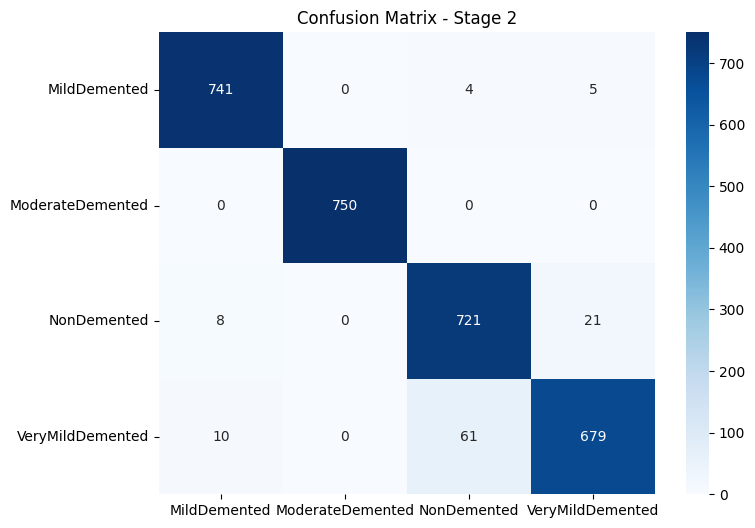

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import os

# -------------------------------
# 1️⃣ الإعدادات والمسارات
# -------------------------------
save_folder = "/content/drive/MyDrive/Alzheimer_Project"
stage1_path = os.path.join(save_folder, "alzheimer_resnet_stage1.h5")
# تأكدي من كتابة الاسم الذي تفضلينه هنا (stage2 أو stage4)
stage2_path = os.path.join(save_folder, "alzheimer_resnet_stage2_final.h5")

img_size = (224, 224)
batch_size = 32

# -------------------------------
# 2️⃣ تجهيز البيانات (Data Pipeline)
# -------------------------------
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    '/content/Train_Data/train',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    '/content/Train_Data/val',
    target_size=img_size,
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False # ضروري جداً لثبات التقييم
)

# -------------------------------
# 3️⃣ تحميل النموذج وتجهيز الـ Fine-Tuning
# -------------------------------
if not os.path.exists(stage1_path):
    print(f"❌ Stage 1 model NOT FOUND at {stage1_path}")
else:
    print("✅ Stage 1 model found! Loading for Stage 2...")
    model = load_model(stage1_path)

    # التحقق من مكان الـ Base Model (ResNet50)
    # أحياناً يكون النموذج عبارة عن Sequential يحتوي على ResNet كأول طبقة
    if hasattr(model.layers[0], 'layers'):
        base_model = model.layers[0]
    else:
        # البحث عن الطبقة التي اسمها يحتوي على resnet
        base_model = next((l for l in model.layers if 'resnet' in l.name.lower()), model.layers[0])

    base_model.trainable = True

    # تجميد كل الطبقات عدا آخر 50 طبقة من الـ Base Model
    print(f"Unfreezing last 50 layers of {base_model.name}...")
    for layer in base_model.layers[:-50]:
        layer.trainable = False
    for layer in base_model.layers[-50:]:
        layer.trainable = True

    # إعادة التجميع بـ Learning Rate منخفض جداً
    model.compile(
        optimizer=optimizers.Adam(learning_rate=1e-5),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # -------------------------------
    # 4️⃣ الـ Callbacks
    # -------------------------------
    callbacks = [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_accuracy',
            patience=6,
            restore_best_weights=True,
            verbose=1
        ),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.2,
            patience=3,
            min_lr=1e-7,
            verbose=1
        )
    ]

    # -------------------------------
    # 5️⃣ التدريب
    # -------------------------------
    print("\n🚀 Starting Stage 2 Fine-Tuning...")
    history_stage2 = model.fit(
        train_generator,
        epochs=25,
        validation_data=val_generator,
        callbacks=callbacks,
        verbose=1
    )

    model.save(stage2_path)
    print(f"✅ Stage 2 model saved at: {stage2_path}")

    # -------------------------------
    # 6️⃣ التقييم النهائي
    # -------------------------------
    print("\n📊 Generating Final Reports...")
    val_generator.reset() # تأكيد إعادة ضبط المؤشر

    preds = model.predict(val_generator)
    y_pred = np.argmax(preds, axis=1)
    y_true = val_generator.classes

    class_names = list(val_generator.class_indices.keys())

    print("\n📜 Classification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title("Confusion Matrix - Stage 2")
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# --- 1. Configuration and Paths ---
save_folder = "/content/drive/MyDrive/Alzheimer_Project"
model_path = os.path.join(save_folder, "alzheimer_resnet_stage2_final.h5")

# Final convolutional layer for ResNet50 (responsible for feature extraction)
last_conv_layer_name = "conv5_block3_out"

img_size = (224, 224)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# --- 2. Model Loading ---
if not os.path.exists(model_path):
    print(f"Model NOT FOUND at {model_path}")
else:
    print(" Loading Model...")
    model = load_model(model_path)

    # Access ResNet50 Base within the model architecture
    if hasattr(model.layers[0], 'layers'):
        base_model = model.layers[0]
    else:
        # Search for the layer containing 'resnet' in its name
        base_model = next((l for l in model.layers if 'resnet' in l.name.lower()), model.layers[0])

    # --- 3. Grad-CAM Algorithm Implementation ---
    def get_gradcam(img_array, model, last_conv_layer_name, pred_index=None):
        # Create a sub-model that maps the input image to the activations of the last conv layer as well as the output predictions
        grad_model = tf.keras.models.Model(
            [model.inputs], [base_model.get_layer(last_conv_layer_name).output, model.output]
        )

        # Compute the gradient of the top predicted class for the input image
        # with respect to the activations of the last conv layer
        with tf.GradientTape() as tape:
            last_conv_layer_output, preds = grad_model(img_array)
            if pred_index is None:
                pred_index = tf.argmax(preds[0])
            class_channel = preds[:, pred_index]

        # Calculate gradients of the output class with respect to the last conv layer output
        grads = tape.gradient(class_channel, last_conv_layer_output)

        # Vector of global average gradients (pooled gradients)
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

        # Weight the channels of the last conv layer output by the pooled gradients
        last_conv_layer_output = last_conv_layer_output[0]
        heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
        heatmap = tf.squeeze(heatmap)

        # Apply ReLU to keep only positive features and normalize the heatmap
        heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
        return heatmap.numpy()

    # --- 4. Visualization Function ---
    def display_gradcam(img_path, heatmap, alpha=0.4):
        # Load and prepare original image
        img = load_img(img_path)
        img = img_to_array(img)

        # Resize heatmap to match the original image dimensions
        heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

        # Convert heatmap to RGB and apply Jet colormap
        heatmap = np.uint8(255 * heatmap)
        heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

        # Superimpose the heatmap on the original image
        superimposed_img = heatmap * alpha + img
        superimposed_img = np.uint8(superimposed_img)

        # Display Original vs Grad-CAM results
        plt.figure(figsize=(10, 5))
        plt.subplot(1, 2, 1)
        plt.imshow(img_to_array(load_img(img_path)) / 255.0)
        plt.title("Original Image")
        plt.axis('off')

        plt.subplot(1, 2, 2)
        plt.imshow(superimposed_img)
        plt.title("Grad-CAM Heatmap")
        plt.axis('off')
        plt.show()

    # --- 5. Inference and Execution ---
    test_img_path = "/content/Train_Data/test/ModerateDemented/moderateDem0.jpg"

    if os.path.exists(test_img_path):
        # Image preprocessing
        img = load_img(test_img_path, target_size=img_size)
        img_array = img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)
        img_array = preprocess_input(img_array)

        # Predict class and confidence
        preds = model.predict(img_array)
        pred_index = np.argmax(preds[0])
        pred_class = class_names[pred_index]
        confidence = preds[0][pred_index]

        print(f" Predicted Class: {pred_class} (Confidence: {confidence:.2f})")

        # Generate and display Grad-CAM
        heatmap = get_gradcam(img_array, model, last_conv_layer_name, pred_index=pred_index)
        display_gradcam(test_img_path, heatmap)
    else:
        print(f" Test Image NOT FOUND at {test_img_path}")

 Loading Model...


 Test Image NOT FOUND at /content/Train_Data/test/ModerateDemented/moderateDem0.jpg


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# --- 1. Settings and Directory Paths ---
base_folder = "/content/drive/MyDrive/Alzheimer_Project"

# Path to the final trained model (Stage 2)
model_path = os.path.join(base_folder, "alzheimer_resnet_stage2_final.h5")

# Path to a specific test image for evaluation
test_img_path = "/content/drive/MyDrive/Alzheimer_Final_Processed/test/ModerateDemented/011f9fde-5a8b-43d5-87c6-3eddaa57611b.jpg"

# ResNet50 target layer for feature extraction (Grad-CAM)
last_conv_layer_name = "conv5_block3_out"

# Image specifications and class labels
img_size = (224, 224)
class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# --- 2. Grad-CAM Core Function ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    # Construct a sub-model to extract the last conv layer output and the final prediction
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Compute the gradient of the predicted class with respect to the last conv layer activations
    with tf.GradientTape() as tape:
        last_conv_layer_output, preds = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate the gradients for the specific class channel
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global average pooling of the gradients (Importance of each feature map)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the last conv layer output by the importance of each feature map
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to retain only positive influence and normalize the heatmap (0-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 3. Execution and Visualization ---
if not os.path.exists(model_path):
    print(f"❌ Model NOT FOUND at {model_path}")
elif not os.path.exists(test_img_path):
    print(f"❌ Test Image NOT FOUND at {test_img_path}")
else:
    print("✅ Loading Model and Image...")
    model = load_model(model_path)

    # Load and preprocess the test image
    img = load_img(test_img_path, target_size=img_size)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = preprocess_input(img_array)

    # --- Step 1: Model Prediction ---
    preds = model.predict(img_array)
    pred_index = np.argmax(preds[0])
    pred_class = class_names[pred_index]
    confidence = preds[0][pred_index]

    print(f"\n📸 Test Result: Predicted Class: '{pred_class}' (Confidence: {confidence:.2f})")

    # --- Step 2: Heatmap Generation ---
    heatmap = make_gradcam_heatmap(img_array, model, last_conv_layer_name)

    # --- Step 3: Superimpose Heatmap and Display Results ---
    # Load original image for visualization using OpenCV
    img_original = cv2.imread(test_img_path)

    # Resize heatmap to match the original image resolution
    heatmap_resized = cv2.resize(heatmap, (img_original.shape[1], img_original.shape[0]))

    # Convert heatmap to RGB and apply Jet color mapping
    heatmap_colored = np.uint8(255 * heatmap_resized)
    heatmap_colored = cv2.applyColorMap(heatmap_colored, cv2.COLORMAP_JET)

    # Superimpose the colored heatmap onto the original image (Alpha = 0.4)
    superimposed_img = heatmap_colored * 0.4 + img_original
    superimposed_img = np.uint8(superimposed_img)

    # Plot results: Original, Heatmap, and Superimposed view
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 3, 1)
    plt.imshow(cv2.cvtColor(img_original, cv2.COLOR_BGR2RGB))
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(heatmap, cmap='jet')
    plt.title("Grad-CAM Heatmap")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(superimposed_img, cv2.COLOR_BGR2RGB))
    plt.title(f"Grad-CAM (Pred: {pred_class})")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

✅ Loading Model and Image...


1/1 ━━━━━━━━━━━━━━━━━━━━ 5s 5s/step

📸 Test Result: Predicted Class: 'ModerateDemented' (Confidence: 1.00)


ValueError: No such layer: conv5_block3_out. Existing layers are: ['resnet50', 'global_average_pooling2d_1', 'batch_normalization_1', 'dense_2', 'dropout_1', 'dense_3'].

/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_2']]
Received: inputs=Tensor(shape=(1, 224, 224, 3))
  warnings.warn(msg)


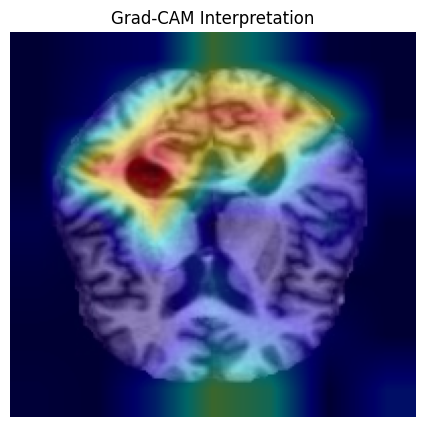

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.applications.resnet50 import preprocess_input
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

# --- 1. Configuration and Paths ---
save_folder = "/content/drive/MyDrive/Alzheimer_Project"
model_path = os.path.join(save_folder, "alzheimer_resnet_stage2_final.h5")
test_img_path = "/content/drive/MyDrive/Alzheimer_Final_Processed/test/ModerateDemented/2ebaae84-5b86-4a72-a212-f548006a6179.jpg"

class_names = ['MildDemented', 'ModerateDemented', 'NonDemented', 'VeryMildDemented']

# --- 2. Grad-CAM Implementation for Nested Models ---
def make_gradcam_heatmap(img_array, model, last_conv_layer_name):
    # Access the ResNet50 base layer from the Sequential model
    res_layer = model.get_layer("resnet50")

    # Create a sub-model to extract features from the last conv layer and the ResNet output
    inner_model = tf.keras.models.Model(
        [res_layer.inputs], [res_layer.get_layer(last_conv_layer_name).output, res_layer.output]
    )

    with tf.GradientTape() as tape:
        # 1. Forward pass through the ResNet base to get feature maps
        last_conv_layer_output, res_output = inner_model(img_array)

        # 2. Sequential forward pass through the top classification head
        x = model.get_layer("global_average_pooling2d_1")(res_output)
        x = model.get_layer("batch_normalization_1")(x)
        x = model.get_layer("dense_2")(x)
        x = model.get_layer("dropout_1")(x)
        preds = model.get_layer("dense_3")(x)

        # 3. Identify the target class for visualization (Top Prediction)
        pred_index = tf.argmax(preds[0])
        class_channel = preds[:, pred_index]

    # Calculate gradients of the target class with respect to the last conv layer output
    grads = tape.gradient(class_channel, last_conv_layer_output)

    # Global average pooling of the gradients
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Weight the feature maps by the importance of the gradients
    last_conv_layer_output = last_conv_layer_output[0]
    heatmap = last_conv_layer_output @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Apply ReLU to keep only positive contributions and normalize (0-1)
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

# --- 3. Execution and Visualization ---
if os.path.exists(model_path) and os.path.exists(test_img_path):
    # Load the trained model
    model = load_model(model_path)

    # Image preprocessing
    img = load_img(test_img_path, target_size=(224, 224))
    img_array = preprocess_input(np.expand_dims(img_to_array(img), axis=0))

    # Generate Heatmap for the final convolutional block
    heatmap = make_gradcam_heatmap(img_array, model, "conv5_block3_out")

    # Image Post-processing and Superimposition
    img_cv = cv2.imread(test_img_path)
    heatmap_resized = cv2.resize(heatmap, (img_cv.shape[1], img_cv.shape[0]))
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap_resized), cv2.COLORMAP_JET)

    # Blend original image with the heatmap
    superimposed = cv2.addWeighted(img_cv, 0.6, heatmap_colored, 0.4, 0)
    superimposed = cv2.cvtColor(superimposed, cv2.COLOR_BGR2RGB)

    # Display results
    plt.figure(figsize=(10, 5))
    plt.imshow(superimposed)
    plt.title(f"Grad-CAM Interpretation")
    plt.axis('off')
    plt.show()
else:
    print("❌ Error: Check model or image paths.")